In [ ]:
from IPython.display import clear_output
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from LatentEvolution.zapbench_data import load_sparse_activity
from LatentEvolution.zapbench_config import CONDITIONS, DataConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")
torch.set_float32_matmul_precision('high')

using device: cuda


/workspace/.conda_envs/neural-graph-linux/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


## load data

In [2]:
# hyperparameters
L = 5  # latent dimensions (2^L = 32 states)
K = 4  # kernel length (400ms at 100ms bins)
NUM_STATES = 2 ** L
BIN_SIZE_MS = 100.0  # 100ms bins

# precompute all binary configurations: (32, 5)
all_configs = torch.zeros(NUM_STATES, L, device=device)
for i in range(NUM_STATES):
    for j in range(L):
        all_configs[i, j] = (i >> j) & 1

print(f"L={L}, NUM_STATES={NUM_STATES}, K={K}, bin_size={BIN_SIZE_MS}ms")
print(f"all_configs shape: {all_configs.shape}")

L=5, NUM_STATES=32, K=4, bin_size=100.0ms
all_configs shape: torch.Size([32, 5])


In [3]:
# load all training conditions
from LatentEvolution.zapbench_config import DataSplit

data_cfg = DataConfig()
data_split = DataSplit()

# get train and val ranges
train_ranges = data_split.get_ranges("train")
val_ranges = data_split.get_ranges("val")

print("training conditions:")
for name, start, end in train_ranges:
    print(f"  {name}: bins {start}-{end} ({end-start} frames)")

print("\nvalidation conditions:")
for name, start, end in val_ranges:
    print(f"  {name}: bins {start}-{end} ({end-start} frames)")

training conditions:
  gain: bins 1-454 (453 frames)
  dots: bins 650-1890 (1240 frames)
  flash: bins 2423-2881 (458 frames)
  turning: bins 3736-4653 (917 frames)
  position: bins 5048-5460 (412 frames)
  open_loop: bins 5639-6327 (688 frames)
  rotation: bins 6624-7082 (458 frames)
  dark: bins 7280-7698 (418 frames)

validation conditions:
  gain: bins 454-519 (65 frames)
  dots: bins 1890-2067 (177 frames)
  flash: bins 2881-2946 (65 frames)
  turning: bins 4653-4784 (131 frames)
  position: bins 5460-5519 (59 frames)
  open_loop: bins 6327-6425 (98 frames)
  rotation: bins 7082-7147 (65 frames)
  dark: bins 7698-7758 (60 frames)


In [4]:
# load data for a list of ranges, concatenate along time
def load_ranges(ranges, bin_size_ms):
    """load and concatenate data from multiple ranges.

    returns: obs_times, obs_vals, counts, total_bins, range_boundaries
    """
    all_obs_times = []
    all_obs_vals = []
    range_boundaries = [0]
    total_bins = 0

    for name, start, end in ranges:
        # load this range
        obs_times, obs_vals, counts, num_bins = load_sparse_activity(
            traces_path=data_cfg.traces_path,
            ephys_path=data_cfg.ephys_path,
            bin_size_ms=bin_size_ms,
            time_slice=slice(start, end),
        )

        # offset times by current total
        obs_times_offset = obs_times + total_bins
        all_obs_times.append(obs_times_offset)
        all_obs_vals.append(obs_vals)

        total_bins += num_bins
        range_boundaries.append(total_bins)
        print(f"  loaded {name}: {num_bins} bins, total now {total_bins}")

    # concatenate along observation dimension (K)
    obs_times_cat = torch.cat(all_obs_times, dim=1)
    obs_vals_cat = torch.cat(all_obs_vals, dim=1)
    counts_cat = torch.tensor([obs_times_cat.shape[1]] * obs_times_cat.shape[0])

    return obs_times_cat, obs_vals_cat, counts_cat, total_bins, range_boundaries

print("loading training data...")
train_obs_times, train_obs_vals, train_counts, train_T, train_boundaries = load_ranges(
    train_ranges, BIN_SIZE_MS
)
N_full = train_obs_times.shape[0]
print(f"\ntotal: {N_full} neurons, {train_T} bins, {train_obs_times.shape[1]} obs per neuron")

loading training data...
  loaded gain: 4140 bins, total now 4140
  loaded dots: 11333 bins, total now 15473
  loaded flash: 4186 bins, total now 19659
  loaded turning: 8381 bins, total now 28040
  loaded position: 3766 bins, total now 31806
  loaded open_loop: 6288 bins, total now 38094
  loaded rotation: 4186 bins, total now 42280
  loaded dark: 3820 bins, total now 46100

total: 71721 neurons, 46100 bins, 5044 obs per neuron


In [5]:
# use all neurons (no subsampling)
N = N_full
T = train_T

# use raw ΔF/F₀ values (clamped to [-0.25, 1.5])
# shift to make positive: [0, 1.75]
BASELINE_SHIFT = 0.25
train_obs_vals_norm = train_obs_vals + BASELINE_SHIFT

print(f"using all {N} neurons")
print(f"T={T} bins, {train_obs_times.shape[1]} observations per neuron")
print(f"observation density: {train_obs_times.shape[1] / T * 100:.1f}%")
print(f"data range: [{train_obs_vals_norm.min().item():.3f}, {train_obs_vals_norm.max().item():.3f}]")
print(f"(raw ΔF/F₀ shifted by {BASELINE_SHIFT} to make positive)")

# compute bins per frame
BINS_PER_FRAME = T / train_obs_times.shape[1]
print(f"bins per frame: {BINS_PER_FRAME:.2f} ({BINS_PER_FRAME * 100:.0f}ms per frame)")

using all 71721 neurons
T=46100 bins, 5044 observations per neuron
observation density: 10.9%
data range: [0.002, 1.750]
(raw ΔF/F₀ shifted by 0.25 to make positive)
bins per frame: 9.14 (914ms per frame)


# Discrete HMM


**latent state**: z(t) ∈ {0,1}^L (L=5, 32 configurations)

**evolver**: P(z(t+1) | z(t)) is 2^L × 2^L transition matrix

**decoder**: logit P(S_i(t)=1 | z(t)) = W_i · z(t) + b_i

**observation model**:
```
γ_i(t) = sigmoid(W_i · z(t) + b_i)
μ_i(t) = Σ_k w_k · γ_i(t-k)
v_i(t) = Σ_k w_k² · γ_i(t-k) · (1 - γ_i(t-k)) + σ²
y_i(t) ~ Normal(μ_i(t), v_i(t))
```

all probabilities parameterized as logits

## model parameters (all in log space / logits)

In [ ]:
# transition matrix - initialize with self-transition bias so states persist
trans_logits_base = nn.Parameter(torch.eye(NUM_STATES, device=device) * 2.0)

# initial state logits
init_logits = nn.Parameter(torch.zeros(NUM_STATES, device=device))

# decoder: W (N, L), b (N)
# larger weights for more differentiation between states
W_dec = nn.Parameter(torch.randn(N, L, device=device) * 0.5)
b_dec = nn.Parameter(torch.zeros(N, device=device))

# per-neuron scale factor (learned)
# α_i captures depth, cell type, expression level, etc.
log_alpha = nn.Parameter(torch.zeros(N, device=device))

# kernel (positive via softplus, normalized to mean 1)
kernel_raw = nn.Parameter(torch.linspace(1.0, 0.1, K, device=device))

# noise log-variance
log_sigma_sq = nn.Parameter(torch.tensor(0.0, device=device))

def get_trans_matrix():
    """row-stochastic transition matrix in log space."""
    return F.log_softmax(trans_logits_base, dim=1)

def get_init_dist():
    """initial distribution in log space"""
    return F.log_softmax(init_logits, dim=0)

def get_kernel():
    """kernel weights, normalized to mean 1 for identifiability."""
    k = F.softplus(kernel_raw)
    return k / k.mean()  # normalize to mean 1

def get_alpha():
    """per-neuron scale factors (positive)."""
    return torch.exp(log_alpha)

def get_sigma_sq():
    return torch.exp(log_sigma_sq)

def decode_all_states():
    """decode all states to per-neuron gamma values.

    use softplus to ensure positive outputs (calcium must be positive).
    """
    # linear + softplus: gamma = softplus(W @ z + b)
    linear_out = all_configs @ W_dec.T + b_dec  # (NUM_STATES, N)
    return F.softplus(linear_out)  # positive outputs

print(f"trans_logits_base diagonal: {trans_logits_base.diag().mean().item():.2f}")
print(f"W_dec: {W_dec.shape}, b_dec: {b_dec.shape}")
print(f"log_alpha: {log_alpha.shape}")
print(f"kernel (mean-normalized): {get_kernel()}")

# visualize initial transition matrix
with torch.no_grad():
    init_trans = torch.exp(get_trans_matrix())
    print(f"\ninitial self-transition prob: {init_trans.diag().mean().item():.4f}")

# check decoder differentiation
with torch.no_grad():
    gamma_all = decode_all_states()
    print(f"\ngamma (softplus) range: [{gamma_all.min().item():.3f}, {gamma_all.max().item():.3f}]")
    print(f"gamma std across states (per neuron): {gamma_all.std(dim=0).mean().item():.4f}")
    print(f"alpha range: [{get_alpha().min().item():.3f}, {get_alpha().max().item():.3f}]")

In [ ]:
def decode_to_gamma(state_idx):
    """decode latent state index to per-neuron values (softplus for positive output).

    state_idx: int or (T,) tensor of state indices
    returns: (N,) or (T, N) tensor of gamma values (positive)
    """
    z = all_configs[state_idx]  # (L,) or (T, L)
    linear_out = z @ W_dec.T + b_dec  # (N,) or (T, N)
    return F.softplus(linear_out)

# decode_all_states is defined in cell-8

# test
gamma_all = decode_all_states()
print(f"gamma_all shape: {gamma_all.shape}")
print(f"gamma range: [{gamma_all.min().item():.3f}, {gamma_all.max().item():.3f}]")
print(f"gamma mean: {gamma_all.mean().item():.3f}")
print(f"gamma std across states: {gamma_all.std(dim=0).mean().item():.4f}")

## observation likelihood

for each observation y_i(t), compute log P(y_i(t) | z(t-K+1:t))

the mean and variance depend on γ_i over the kernel window

In [ ]:
# for tractability, we'll use an iterative approach:
# 1. given current posterior over z(t), compute expected gamma_i(t) for all t
# 2. compute observation likelihoods using kernel convolution of expected gammas
# 3. run forward-backward to update posterior
# 4. repeat

def compute_expected_gamma(log_posterior):
    """compute expected gamma_i(t) given log posterior over states.

    log_posterior: (T, NUM_STATES) log P(z(t)=s | observations)
    returns: (T, N) expected gamma values (linear, not constrained to [0,1])
    """
    posterior = torch.exp(log_posterior)  # (T, NUM_STATES)
    gamma_all = decode_all_states()  # (NUM_STATES, N)
    return posterior @ gamma_all  # (T, N)

def compute_emission_loglik(gamma_history, obs_times, obs_vals, kernel, sigma_sq):
    """compute log-likelihood of observations given gamma history.

    with linear decoder, uses fixed Gaussian variance.

    gamma_history: (T, N) expected gamma values
    obs_times: (N, K_obs) observation times per neuron
    obs_vals: (N, K_obs) observation values
    kernel: (K,) positive kernel weights
    sigma_sq: noise variance

    returns: (T,) log-likelihood contribution at each time
    """
    T_len, N_neurons = gamma_history.shape
    K_len = kernel.shape[0]

    # convolve gamma with kernel: (N, T)
    gamma_T = gamma_history.T  # (N, T)
    gamma_padded = F.pad(gamma_T, (K_len - 1, 0), mode='constant', value=0.0)
    gamma_3d = gamma_padded.unsqueeze(1)  # (N, 1, T+K-1)
    kernel_3d = kernel.flip(0).view(1, 1, K_len)
    mu = F.conv1d(gamma_3d, kernel_3d).squeeze(1)  # (N, T) predicted mean

    # fixed variance (linear decoder)
    var = sigma_sq

    # gather at observation times
    mu_obs = mu.gather(1, obs_times)  # (N, K_obs)

    # gaussian log-likelihood
    diff = obs_vals - mu_obs
    log_lik = -0.5 * (diff ** 2) / var - 0.5 * torch.log(var)  # (N, K_obs)

    # aggregate by time: scatter back to (T,)
    log_lik_by_time = torch.zeros(T_len, device=device)
    for n in range(N_neurons):
        log_lik_by_time.scatter_add_(0, obs_times[n], log_lik[n])

    return log_lik_by_time

print("emission functions defined (linear decoder, fixed variance)")

<cell_type>markdown</cell_type>## forward-backward algorithm

HMM inference with 32 states. emission at time t is computed from expected gamma.

In [ ]:
# data will be moved to GPU in the training cell
print(f"training data shape: {train_obs_times.shape}")
print(f"will move to GPU during training")

In [ ]:
def get_obs_at_time(t, time_boundaries, neurons_sorted, vals_sorted):
    """get observations at time t."""
    start = time_boundaries[t].item()
    end = time_boundaries[t + 1].item()
    return neurons_sorted[start:end], vals_sorted[start:end]

def compute_all_emissions_vectorized(expected_gamma, obs_times_gpu, obs_vals_gpu,
                                      gamma_all_states, kernel, sigma_sq, T_len, N):
    """compute emission log-likelihood for all times and states at once.

    with linear decoder, we use fixed Gaussian variance (no Bernoulli variance term).

    returns: (T, NUM_STATES) emission log-likelihoods
    """
    K_len = kernel.shape[0]

    # compute past contributions using convolution (excluding current time)
    gamma_T = expected_gamma.T  # (N, T)

    if K_len > 1:
        past_kernel = kernel[1:]  # (K-1,)
        gamma_padded = F.pad(gamma_T, (K_len - 1, 0), mode='constant', value=0.0)
        gamma_3d = gamma_padded.unsqueeze(1)
        past_kernel_3d = past_kernel.flip(0).view(1, 1, K_len - 1)
        past_contrib = F.conv1d(gamma_3d, past_kernel_3d).squeeze(1)  # (N, T)
    else:
        past_contrib = torch.zeros(N, T_len, device=expected_gamma.device)

    gamma_current = gamma_all_states  # (NUM_STATES, N)
    mu_current = kernel[0] * gamma_current  # (NUM_STATES, N)

    K_obs = obs_times_gpu.shape[1]
    obs_times_clamped = obs_times_gpu.clamp(max=T_len - 1)
    past_at_obs = past_contrib.gather(1, obs_times_clamped)  # (N, K_obs)

    # mean per state per observation: mu_current + past_contrib
    mu_per_state_obs = mu_current.unsqueeze(2) + past_at_obs.unsqueeze(0)  # (NUM_STATES, N, K_obs)

    # fixed variance (no Bernoulli term with linear decoder)
    var = sigma_sq  # scalar

    diff = obs_vals_gpu.unsqueeze(0) - mu_per_state_obs  # (NUM_STATES, N, K_obs)
    log_lik_obs = -0.5 * (diff ** 2) / var - 0.5 * torch.log(var)  # (NUM_STATES, N, K_obs)

    # vectorized scatter using index_add
    emissions = torch.zeros(T_len, NUM_STATES, device=expected_gamma.device)
    log_lik_flat = log_lik_obs.reshape(NUM_STATES, -1).T  # (N*K_obs, NUM_STATES)
    times_flat = obs_times_clamped.flatten()
    emissions.index_add_(0, times_flat, log_lik_flat)

    return emissions

def forward_pass(emissions, log_trans, log_init, T_len, num_states):
    """forward pass of HMM."""
    log_alpha = torch.zeros(T_len, num_states, device=emissions.device)
    log_alpha[0] = log_init + emissions[0]
    log_alpha[0] = log_alpha[0] - torch.logsumexp(log_alpha[0], dim=0)

    for t in range(1, T_len):
        log_alpha[t] = torch.logsumexp(log_alpha[t-1].unsqueeze(1) + log_trans, dim=0) + emissions[t]
        log_alpha[t] = log_alpha[t] - torch.logsumexp(log_alpha[t], dim=0)

    return log_alpha

def backward_pass(emissions, log_trans, T_len, num_states):
    """backward pass of HMM."""
    log_beta = torch.zeros(T_len, num_states, device=emissions.device)

    for t in range(T_len - 2, -1, -1):
        log_beta[t] = torch.logsumexp(
            log_trans + emissions[t + 1].unsqueeze(0) + log_beta[t + 1].unsqueeze(0), dim=1
        )
        log_beta[t] = log_beta[t] - torch.logsumexp(log_beta[t], dim=0)

    return log_beta

def forward_backward_vectorized(emissions, log_trans, log_init, T_len):
    """run forward-backward with precomputed emissions."""
    num_states = emissions.shape[1]

    log_alpha = forward_pass(emissions, log_trans, log_init, T_len, num_states)
    log_beta = backward_pass(emissions, log_trans, T_len, num_states)

    log_posterior = log_alpha + log_beta
    log_posterior = log_posterior - torch.logsumexp(log_posterior, dim=1, keepdim=True)

    return log_posterior

print("vectorized forward-backward defined (linear decoder, fixed variance)")

## E-step: iterate forward-backward with updated expected gamma

In [ ]:
def e_step_vectorized(log_posterior, obs_times_gpu, obs_vals_gpu,
                       log_trans, log_init, kernel, sigma_sq, T_len, N, n_iters=3):
    """E-step: iterate forward-backward to refine posterior (vectorized)."""
    gamma_all_states = decode_all_states().detach()  # (NUM_STATES, N)

    for i in range(n_iters):
        # compute expected gamma from current posterior
        expected_gamma = compute_expected_gamma(log_posterior.detach())

        # compute all emissions vectorized
        with torch.no_grad():
            emissions = compute_all_emissions_vectorized(
                expected_gamma, obs_times_gpu, obs_vals_gpu,
                gamma_all_states, kernel, sigma_sq, T_len, N
            )

        # run forward-backward (no gradients needed in E-step)
        with torch.no_grad():
            log_posterior = forward_backward_vectorized(emissions, log_trans, log_init, T_len)

        # compute entropy for monitoring
        entropy = -(torch.exp(log_posterior) * log_posterior).sum()
        print(f"  E-step iter {i}: entropy = {entropy.item():.2f}")

        # cleanup
        del emissions, expected_gamma

    return log_posterior.detach()

print("e_step_vectorized defined")

## M-step: update parameters given posterior

In [ ]:
def compute_expected_log_likelihood_vectorized(log_posterior, obs_times_gpu, obs_vals_gpu,
                                                log_trans, log_init, kernel, sigma_sq, T_len, N):
    """compute expected complete-data log-likelihood for M-step (vectorized)."""
    posterior = torch.exp(log_posterior)  # (T, NUM_STATES)
    gamma_all_states = decode_all_states()  # (NUM_STATES, N)
    expected_gamma = compute_expected_gamma(log_posterior)

    # transition term (vectorized)
    trans_term = torch.einsum('ti,tj,ij->', posterior[:-1], posterior[1:], log_trans)

    # initial term
    init_term = (posterior[0] * log_init).sum()

    # emission term: compute all emissions and weight by posterior
    emissions = compute_all_emissions_vectorized(
        expected_gamma, obs_times_gpu, obs_vals_gpu,
        gamma_all_states, kernel, sigma_sq, T_len, N
    )
    emit_term = (posterior * emissions).sum()

    return trans_term + init_term + emit_term

def m_step_vectorized(log_posterior, obs_times_gpu, obs_vals_gpu,
                      params_list, T_len, N, n_iters=10, lr=0.01):
    """M-step: optimize parameters to maximize expected log-likelihood."""
    optimizer = torch.optim.Adam(params_list, lr=lr)

    # detach posterior once (it's fixed during M-step)
    posterior_detached = log_posterior.detach()

    for i in range(n_iters):
        optimizer.zero_grad(set_to_none=True)  # more memory efficient

        log_trans = get_trans_matrix()
        log_init = get_init_dist()
        kernel = get_kernel()
        sigma_sq = get_sigma_sq()

        neg_ell = -compute_expected_log_likelihood_vectorized(
            posterior_detached, obs_times_gpu, obs_vals_gpu,
            log_trans, log_init, kernel, sigma_sq, T_len, N
        )

        neg_ell.backward()
        optimizer.step()

        # cleanup intermediate tensors
        del neg_ell

    # final evaluation
    with torch.no_grad():
        log_trans = get_trans_matrix()
        log_init = get_init_dist()
        kernel = get_kernel()
        sigma_sq = get_sigma_sq()

        ell = compute_expected_log_likelihood_vectorized(
            posterior_detached, obs_times_gpu, obs_vals_gpu,
            log_trans, log_init, kernel, sigma_sq, T_len, N
        )

    return ell.item()

print("m_step_vectorized defined")

## run EM

train on all conditions (100ms bins, L=5 latent dims, 32 states)

In [ ]:
# training data summary
T_subset = T
print(f"training on T={T_subset} bins, N={N} neurons")
print(f"total observations: {train_obs_times.shape[0] * train_obs_times.shape[1]}")

# load validation data (all neurons)
print("\nloading validation data...")
val_obs_times_full, val_obs_vals_full, val_counts, val_T, val_boundaries = load_ranges(
    val_ranges, BIN_SIZE_MS
)

# apply same shift as training data (no per-neuron normalization)
val_obs_vals_norm = val_obs_vals_full + BASELINE_SHIFT

# create expected variable names for later cells
val_obs_times = val_obs_times_full

print(f"validation: {val_T} bins, {val_obs_times.shape[1]} obs per neuron")
print(f"validation data range: [{val_obs_vals_norm.min().item():.3f}, {val_obs_vals_norm.max().item():.3f}]")

In [ ]:
# ===========================================================================
# SECTION 1: EM FITTING (stochastic)
# sample 1 random 32-frame window per EM step
# ===========================================================================

# training hyperparameters
WINDOW_FRAMES = 32
WINDOW_BINS = int(round(WINDOW_FRAMES * BINS_PER_FRAME))
N_WINDOWS_PER_STEP = 1  # stochastic EM: one window at a time

# smoothness prior: encourage self-transitions
SELF_TRANS_WEIGHT = 0.1  # weight for self-transition regularization (higher = smoother)

# fixed sigma (not learned)
FIXED_SIGMA_SQ = 0.01  # frozen noise variance

print(f"stochastic EM: {N_WINDOWS_PER_STEP} window × {WINDOW_FRAMES} frames ({WINDOW_BINS} bins)")
print(f"self-transition regularization weight: {SELF_TRANS_WEIGHT}")
print(f"FIXED sigma_sq: {FIXED_SIGMA_SQ} (not learned)")
print(f"total neurons: {N}")

# reinitialize parameters
with torch.no_grad():
    # stronger self-transition initialization (smoother prior)
    trans_logits_base.data = torch.eye(NUM_STATES, device=device) * 4.0
    init_logits.data = torch.zeros(NUM_STATES, device=device)
    W_dec.data = torch.randn(N, L, device=device) * 0.5
    b_dec.data = torch.zeros(N, device=device)

    # initialize log_alpha from neuron means
    # target: α * kernel_sum * gamma ≈ mean(y)
    # assume kernel_sum ≈ 4, gamma ≈ 1, so α ≈ mean(y) / 4
    neuron_mean = train_obs_vals_norm.mean(dim=1)
    init_alpha = (neuron_mean / 4.0).clamp(min=0.01)
    log_alpha.data = torch.log(init_alpha.to(device))

    # kernel (will be mean-normalized)
    kernel_raw.data = torch.linspace(1.0, 0.1, K, device=device)
    # set fixed sigma_sq (won't be in params_list)
    log_sigma_sq.data = torch.tensor(np.log(FIXED_SIGMA_SQ), device=device)

print("parameters initialized (with sticky transition prior, frozen sigma)")
print(f"alpha initialized from neuron means: [{get_alpha().min().item():.3f}, {get_alpha().max().item():.3f}]")

# check initial self-transition
with torch.no_grad():
    init_trans = torch.exp(get_trans_matrix())
    print(f"initial self-transition prob: {init_trans.diag().mean().item():.4f}")
    print(f"sigma: {torch.sqrt(get_sigma_sq()).item():.4f}")
    print(f"kernel (mean-normalized): {get_kernel().cpu().numpy()}")

# EM iterations
n_em_iters = 100
em_lls = []

In [14]:
from IPython.display import clear_output

In [ ]:


def extract_window_obs(obs_times_cpu, obs_vals_cpu, start, window_len):
    """extract only observations within window, move to GPU."""
    N = obs_times_cpu.shape[0]

    # find observations in window (on CPU)
    in_window = (obs_times_cpu >= start) & (obs_times_cpu < start + window_len)

    # get relative times and values for observations in window
    times_rel = (obs_times_cpu - start).clamp(0, window_len - 1)

    # flatten and filter to only in-window observations
    flat_mask = in_window.flatten()
    flat_times = times_rel.flatten()[flat_mask]
    flat_vals = obs_vals_cpu.flatten()[flat_mask]

    # neuron indices for each observation
    neuron_idx = torch.arange(N).unsqueeze(1).expand_as(obs_times_cpu).flatten()[flat_mask]

    # move to GPU
    return (
        flat_times.to(device),
        flat_vals.to(device),
        neuron_idx.to(device),
    )


def compute_emissions_sparse(flat_times, flat_vals, neuron_idx, window_len, N,
                              gamma_all_states, kernel, alpha, sigma_sq):
    """compute emissions from sparse observations.

    includes per-neuron scale factor alpha:
    μ_i = α_i * Σ_k kernel[k] * γ_i(t-k)
    """
    K_len = kernel.shape[0]

    mean_gamma = gamma_all_states.mean(dim=0)
    mu_current = kernel[0] * gamma_all_states  # (NUM_STATES, N)

    if K_len > 1:
        past_weight = kernel[1:].sum()
        past_contrib = past_weight * mean_gamma  # (N,)
    else:
        past_contrib = torch.zeros(N, device=device)

    # mu before scaling: (NUM_STATES, n_obs)
    mu_unscaled = mu_current[:, neuron_idx] + past_contrib[neuron_idx].unsqueeze(0)

    # apply per-neuron scale factor
    alpha_obs = alpha[neuron_idx]  # (n_obs,)
    mu_per_state = alpha_obs.unsqueeze(0) * mu_unscaled  # (NUM_STATES, n_obs)

    diff = flat_vals.unsqueeze(0) - mu_per_state
    log_lik = -0.5 * (diff ** 2) / sigma_sq - 0.5 * torch.log(sigma_sq)

    emissions = torch.zeros(window_len, NUM_STATES, device=device)
    emissions.index_add_(0, flat_times, log_lik.T)

    return emissions


def stochastic_em_step(obs_times_cpu, obs_vals_cpu, window_start, window_len, N,
                        params_list, n_fb_iters=2, n_m_iters=5, lr=0.01,
                        self_trans_weight=0.0):
    """one stochastic EM step with sparse observation loading."""

    # extract only in-window observations (sparse)
    flat_times, flat_vals, neuron_idx = extract_window_obs(
        obs_times_cpu, obs_vals_cpu, window_start, window_len
    )

    n_obs = flat_times.shape[0]
    if n_obs == 0:
        return 0.0

    # E-step
    with torch.no_grad():
        gamma_all_states = decode_all_states()
        log_trans = get_trans_matrix()
        log_init = get_init_dist()
        kernel = get_kernel()
        alpha = get_alpha()
        sigma_sq = get_sigma_sq()

        log_post = torch.full((window_len, NUM_STATES), -np.log(NUM_STATES), device=device)

        for _ in range(n_fb_iters):
            emissions = compute_emissions_sparse(
                flat_times, flat_vals, neuron_idx, window_len, N,
                gamma_all_states, kernel, alpha, sigma_sq
            )
            log_post = forward_backward_vectorized(emissions, log_trans, log_init, window_len)

        posterior = torch.exp(log_post)

    # M-step
    optimizer = torch.optim.Adam(params_list, lr=lr)

    for _ in range(n_m_iters):
        optimizer.zero_grad(set_to_none=True)

        log_trans = get_trans_matrix()
        log_init = get_init_dist()
        kernel = get_kernel()
        alpha = get_alpha()
        sigma_sq = get_sigma_sq()
        gamma_all_states = decode_all_states()

        # transition term
        trans_term = torch.einsum('ti,tj,ij->', posterior[:-1], posterior[1:], log_trans)

        # initial term
        init_term = (posterior[0] * log_init).sum()

        # emission term
        emissions = compute_emissions_sparse(
            flat_times, flat_vals, neuron_idx, window_len, N,
            gamma_all_states, kernel, alpha, sigma_sq
        )
        emit_term = (posterior * emissions).sum()

        # self-transition regularization (smoothness prior)
        trans_matrix = torch.exp(log_trans)
        self_trans_reg = self_trans_weight * trans_matrix.diag().sum()

        total_ell = trans_term + init_term + emit_term + self_trans_reg
        (-total_ell).backward()
        optimizer.step()

    ell = total_ell.item()

    # cleanup
    del flat_times, flat_vals, neuron_idx, emissions, posterior, log_post
    torch.cuda.empty_cache()

    return ell


def visualize_reconstruction_sparse(obs_times_cpu, obs_vals_cpu, viz_neuron_idx,
                                     em_iter, ell, window_len, val_start=100,
                                     title_prefix="validation"):
    """visualize reconstruction using sparse loading."""
    n_viz = len(viz_neuron_idx)

    viz_times = obs_times_cpu[viz_neuron_idx]
    viz_vals = obs_vals_cpu[viz_neuron_idx]

    flat_times, flat_vals, neuron_idx = extract_window_obs(
        viz_times, viz_vals, val_start, window_len
    )

    with torch.no_grad():
        log_trans_f = get_trans_matrix()
        log_init_f = get_init_dist()
        kernel_f = get_kernel()
        alpha_f = get_alpha()
        sigma_sq_f = get_sigma_sq()

        gamma_all_full = decode_all_states()
        gamma_viz = gamma_all_full[:, viz_neuron_idx]
        alpha_viz = alpha_f[viz_neuron_idx]

        emissions = compute_emissions_sparse(
            flat_times, flat_vals, neuron_idx, window_len, n_viz,
            gamma_viz, kernel_f, alpha_viz, sigma_sq_f
        )

        log_posterior_window = forward_backward_vectorized(
            emissions, log_trans_f, log_init_f, window_len
        )
        posterior_window = torch.exp(log_posterior_window)

        # decode: expected_gamma scaled by alpha
        expected_gamma = posterior_window @ gamma_viz  # (window_len, n_viz)

        K_len = kernel_f.shape[0]
        gamma_T = expected_gamma.T  # (n_viz, window_len)
        gamma_padded = F.pad(gamma_T, (K_len - 1, 0), mode='replicate')
        gamma_3d = gamma_padded.unsqueeze(1)
        kernel_3d = kernel_f.flip(0).view(1, 1, K_len)
        pred_unscaled = F.conv1d(gamma_3d, kernel_3d).squeeze(1)  # (n_viz, window_len)

        # apply per-neuron scale
        pred_calcium = alpha_viz.unsqueeze(1) * pred_unscaled

        entropy_per_t = -(posterior_window * log_posterior_window).sum(dim=1)
        mean_entropy = entropy_per_t.mean().item()

    fig, axes = plt.subplots(2, 3, figsize=(14, 6))

    for i in range(n_viz):
        row = i // 3
        col = i % 3
        ax = axes[row, col]

        obs_t = viz_times[i].numpy()
        obs_v = viz_vals[i].numpy()
        pred_v = pred_calcium[i].cpu().numpy()

        vis_end = val_start + window_len
        mask = (obs_t >= val_start) & (obs_t < vis_end)
        obs_t_rel = obs_t[mask] - val_start
        obs_v_sub = obs_v[mask]

        ax.scatter(obs_t_rel, obs_v_sub, s=8, alpha=0.6, label='actual', zorder=2)
        ax.plot(pred_v, 'r-', alpha=0.8, linewidth=1.5, label='reconstructed', zorder=1)

        ax.set_xlabel('time bin')
        ax.set_ylabel('calcium')
        var_label = 'low var' if i < 3 else 'high var'
        ax.set_title(f'{var_label}: n{viz_neuron_idx[i].item()} (α={alpha_viz[i].item():.2f})')
        ax.set_xlim(0, window_len)
        if i == 0:
            ax.legend(loc='upper right', fontsize=7)

    trans_diag = torch.exp(log_trans_f).diag().mean().item()
    plt.suptitle(f'{title_prefix} | EM iter {em_iter+1} | ELL: {ell:.0f} | self-trans: {trans_diag:.3f} | entropy: {mean_entropy:.2f}', fontsize=12)
    plt.tight_layout()
    plt.show()

    del flat_times, flat_vals, neuron_idx, emissions, posterior_window
    torch.cuda.empty_cache()


# select neurons for visualization (from training data variance, but will visualize on val)
print("selecting visualization neurons...")
torch.manual_seed(42)
sample_idx = torch.randperm(N)[:1000]
sample_vals = train_obs_vals_norm[sample_idx]
neuron_var = sample_vals.var(dim=1)
sorted_idx = torch.argsort(neuron_var)
viz_local_idx = torch.cat([sorted_idx[:3], sorted_idx[-3:]])
viz_neuron_idx = sample_idx[viz_local_idx]
print(f"viz neurons: {viz_neuron_idx.tolist()}")

print(f"training data on CPU. shape: {train_obs_times.shape}")
print(f"validation data on CPU. shape: {val_obs_times.shape}")

# EM loop
max_start = T - WINDOW_BINS
# NOTE: log_sigma_sq is NOT in params_list (frozen), log_alpha IS learned
params_list = [trans_logits_base, init_logits, W_dec, b_dec, log_alpha, kernel_raw]

print(f"\nstarting stochastic EM (window={WINDOW_BINS} bins, {n_em_iters} iters)...")
print(f"self-transition weight: {SELF_TRANS_WEIGHT}")
print(f"sigma frozen at: {np.sqrt(FIXED_SIGMA_SQ):.4f}")
print(f"learning per-neuron alpha (N={N})")

for em_iter in range(n_em_iters):
    window_start = torch.randint(0, max_start, (1,)).item()

    ell = stochastic_em_step(
        train_obs_times, train_obs_vals_norm, window_start, WINDOW_BINS, N,
        params_list, n_fb_iters=2, n_m_iters=5, lr=0.01,
        self_trans_weight=SELF_TRANS_WEIGHT
    )
    em_lls.append(ell)

    if (em_iter + 1) % 10 == 0 or em_iter == 0:
        clear_output(wait=True)
        print(f"=== EM iter {em_iter + 1}/{n_em_iters} ===")
        print(f"ELL: {ell:.2f}")

        with torch.no_grad():
            trans = torch.exp(get_trans_matrix())
            gamma_all = decode_all_states()
            alpha = get_alpha()
            print(f"self-trans: {trans.diag().mean().item():.4f}")
            print(f"gamma: [{gamma_all.min().item():.3f}, {gamma_all.max().item():.3f}]")
            print(f"alpha: [{alpha.min().item():.3f}, {alpha.max().item():.3f}], mean={alpha.mean().item():.3f}")
            print(f"kernel (mean=1): {get_kernel().cpu().numpy()}")
            print(f"sigma (frozen): {torch.sqrt(get_sigma_sq()).item():.4f}")

        # visualize on VALIDATION data
        visualize_reconstruction_sparse(
            val_obs_times, val_obs_vals_norm, viz_neuron_idx,
            em_iter, ell, WINDOW_BINS, val_start=100,
            title_prefix="VALIDATION"
        )

print("\n=== stochastic EM complete ===")

In [ ]:
# visualize EM fitting results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# expected log-likelihood over EM iterations
axes[0].plot(em_lls, 'b-o', markersize=3)
axes[0].set_xlabel("EM iteration")
axes[0].set_ylabel("expected log-likelihood")
axes[0].set_title("EM convergence")
axes[0].grid(True, alpha=0.3)

# learned transition matrix
with torch.no_grad():
    trans_matrix = torch.exp(get_trans_matrix()).cpu().numpy()

im = axes[1].imshow(trans_matrix, cmap='viridis')
axes[1].set_xlabel('to state')
axes[1].set_ylabel('from state')
axes[1].set_title(f'transition matrix (diag={trans_matrix.diagonal().mean():.3f})')
plt.colorbar(im, ax=axes[1])

# run inference on a sample window to get state trajectory (using sparse function)
sample_start = 1000
with torch.no_grad():
    log_trans_f = get_trans_matrix()
    log_init_f = get_init_dist()
    kernel_f = get_kernel()
    alpha_f = get_alpha()
    sigma_sq_f = get_sigma_sq()
    gamma_all_states = decode_all_states()

    # extract window observations using sparse method
    flat_times, flat_vals, neuron_idx = extract_window_obs(
        train_obs_times, train_obs_vals_norm, sample_start, WINDOW_BINS
    )

    # compute emissions using sparse method
    emissions = compute_emissions_sparse(
        flat_times, flat_vals, neuron_idx, WINDOW_BINS, N,
        gamma_all_states, kernel_f, alpha_f, sigma_sq_f
    )

    log_posterior_sample = forward_backward_vectorized(emissions, log_trans_f, log_init_f, WINDOW_BINS)
    posterior_sample = torch.exp(log_posterior_sample)
    most_likely_state = posterior_sample.argmax(dim=1)

    # cleanup
    del flat_times, flat_vals, neuron_idx, emissions

axes[2].plot(most_likely_state.cpu().numpy(), linewidth=0.5)
axes[2].set_xlabel("time bin (within window)")
axes[2].set_ylabel("most likely state")
axes[2].set_title(f"inferred state trajectory (window at t={sample_start})")

plt.tight_layout()
plt.show()

# posterior entropy
entropy_per_t = -(posterior_sample * log_posterior_sample).sum(dim=1)
print(f"posterior entropy: mean={entropy_per_t.mean().item():.3f}, std={entropy_per_t.std().item():.3f}")
print(f"max entropy (uniform over {NUM_STATES} states): {np.log(NUM_STATES):.3f}")

In [ ]:
# prediction training cells removed - using EM fitting only for now
print("(prediction training section removed)")

In [ ]:
# (removed)

In [ ]:
# (removed)

<cell_type>markdown</cell_type>## validate on held-out validation splits

load same neurons from validation ranges, use learned parameters, infer latent state

In [ ]:
# validation inference using sparse approach (memory-efficient for 71K neurons)

print(f"running validation inference on window ({val_T} bins total)...")

log_trans_frozen = get_trans_matrix().detach()
log_init_frozen = get_init_dist().detach()
kernel_frozen = get_kernel().detach()
alpha_frozen = get_alpha().detach()
sigma_sq_frozen = get_sigma_sq().detach()
gamma_all_frozen = decode_all_states().detach()

# run on a representative window for validation metrics
val_start = val_T // 4  # start at 1/4 of validation data
val_window_len = min(WINDOW_BINS, val_T - val_start)

with torch.no_grad():
    # extract window observations using sparse method
    flat_times, flat_vals, neuron_idx = extract_window_obs(
        val_obs_times, val_obs_vals_norm, val_start, val_window_len
    )

    # compute emissions using sparse method
    val_emissions = compute_emissions_sparse(
        flat_times, flat_vals, neuron_idx, val_window_len, N,
        gamma_all_frozen, kernel_frozen, alpha_frozen, sigma_sq_frozen
    )

    val_log_posterior = forward_backward_vectorized(
        val_emissions, log_trans_frozen, log_init_frozen, val_window_len
    )

    # cleanup sparse data
    del flat_times, flat_vals, neuron_idx, val_emissions

print(f"done. window: t={val_start} to t={val_start + val_window_len}")

In [ ]:
# predict calcium activity from inferred latent state (on validation window)
def predict_calcium_window(log_posterior, kernel, alpha, gamma_all_states):
    """predict calcium activity from posterior over latent states.

    includes per-neuron scale factor alpha:
    μ_i = α_i * Σ_k kernel[k] * γ_i(t-k)

    log_posterior: (window_len, NUM_STATES)
    kernel: (K,) convolution kernel
    alpha: (N,) per-neuron scale factors
    gamma_all_states: (NUM_STATES, N)
    returns: (N, window_len) predicted values
    """
    posterior = torch.exp(log_posterior)  # (window_len, NUM_STATES)
    expected_gamma = posterior @ gamma_all_states  # (window_len, N)

    # convolve with kernel to get predicted mean (before alpha scaling)
    K_len = kernel.shape[0]
    gamma_T = expected_gamma.T  # (N, window_len)
    gamma_padded = F.pad(gamma_T, (K_len - 1, 0), mode='replicate')
    gamma_3d = gamma_padded.unsqueeze(1)  # (N, 1, window_len+K-1)
    kernel_3d = kernel.flip(0).view(1, 1, K_len)
    mu_unscaled = F.conv1d(gamma_3d, kernel_3d).squeeze(1)  # (N, window_len)

    # apply per-neuron scale factor
    mu = alpha.unsqueeze(1) * mu_unscaled  # (N, window_len)

    return mu, expected_gamma.T

# predict on validation window
with torch.no_grad():
    val_mu, val_expected_gamma = predict_calcium_window(
        val_log_posterior, kernel_frozen, alpha_frozen, gamma_all_frozen
    )
print(f"predictions shape: {val_mu.shape} (N, window_len)")

In [ ]:
# evaluate predictions vs actual observations (on validation window)
window_end = val_start + val_window_len

# move validation observation data to GPU for this evaluation
val_obs_times_gpu = val_obs_times.to(device)
val_obs_vals_gpu = val_obs_vals_norm.to(device)

# mask observations within window
obs_mask = (val_obs_times_gpu >= val_start) & (val_obs_times_gpu < window_end)
obs_times_rel = (val_obs_times_gpu - val_start).clamp(0, val_window_len - 1)

# gather predictions at observation times
val_pred_at_obs = val_mu.gather(1, obs_times_rel)  # (N, K_obs)

# apply mask and flatten
pred_flat = val_pred_at_obs[obs_mask]
actual_flat = val_obs_vals_gpu[obs_mask]

# compute metrics
mse = F.mse_loss(pred_flat, actual_flat).item()
mae = (pred_flat - actual_flat).abs().mean().item()

# correlation
pred_centered = pred_flat - pred_flat.mean()
actual_centered = actual_flat - actual_flat.mean()
corr = (pred_centered * actual_centered).sum() / (
    pred_centered.norm() * actual_centered.norm() + 1e-8
)

print(f"validation metrics (window t={val_start} to t={window_end}):")
print(f"  MSE: {mse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  correlation: {corr.item():.4f}")
print(f"  n_observations: {pred_flat.shape[0]}")

In [ ]:
# visualize predictions vs actual for a few neurons
fig, axes = plt.subplots(3, 2, figsize=(14, 8))

for i, ax in enumerate(axes.flat):
    # use neurons from viz_neuron_idx if available, else spread across N
    if i < len(viz_neuron_idx):
        neuron = viz_neuron_idx[i].item()
    else:
        neuron = i * (N // 6)

    # get observations for this neuron (data on CPU)
    obs_t = val_obs_times[neuron].cpu().numpy()
    obs_v = val_obs_vals_norm[neuron].cpu().numpy()
    pred_v = val_mu[neuron].cpu().detach().numpy()

    # show within window for clarity
    mask = (obs_t >= val_start) & (obs_t < window_end)
    obs_t_sub = obs_t[mask] - val_start  # relative to window start
    obs_v_sub = obs_v[mask]

    ax.scatter(obs_t_sub, obs_v_sub, s=5, alpha=0.6, label='actual')
    ax.plot(pred_v, 'r-', alpha=0.7, linewidth=0.5, label='predicted')
    ax.set_xlabel('time bin (within window)')
    ax.set_ylabel('calcium')
    ax.set_title(f'neuron {neuron} (α={alpha_frozen[neuron].item():.3f})')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(0, val_window_len)

plt.suptitle(f'validation predictions (window t={val_start} to {window_end})', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# compare latent state trajectory on sample windows (training vs validation)

sample_start_train = 1000
sample_start_val = 100

with torch.no_grad():
    log_trans_f = get_trans_matrix()
    log_init_f = get_init_dist()
    kernel_f = get_kernel()
    alpha_f = get_alpha()
    sigma_sq_f = get_sigma_sq()
    gamma_all_states = decode_all_states()

    # training window (sparse)
    flat_times, flat_vals, neuron_idx = extract_window_obs(
        train_obs_times, train_obs_vals_norm, sample_start_train, WINDOW_BINS
    )
    train_emissions = compute_emissions_sparse(
        flat_times, flat_vals, neuron_idx, WINDOW_BINS, N,
        gamma_all_states, kernel_f, alpha_f, sigma_sq_f
    )
    train_log_post = forward_backward_vectorized(train_emissions, log_trans_f, log_init_f, WINDOW_BINS)
    train_posterior = torch.exp(train_log_post)
    train_most_likely = train_posterior.argmax(dim=1)
    del flat_times, flat_vals, neuron_idx, train_emissions

    # validation window (sparse)
    flat_times, flat_vals, neuron_idx = extract_window_obs(
        val_obs_times, val_obs_vals_norm, sample_start_val, WINDOW_BINS
    )
    val_emissions = compute_emissions_sparse(
        flat_times, flat_vals, neuron_idx, WINDOW_BINS, N,
        gamma_all_states, kernel_f, alpha_f, sigma_sq_f
    )
    val_log_post = forward_backward_vectorized(val_emissions, log_trans_f, log_init_f, WINDOW_BINS)
    val_posterior_sample = torch.exp(val_log_post)
    val_most_likely = val_posterior_sample.argmax(dim=1)
    del flat_times, flat_vals, neuron_idx, val_emissions

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

# training
axes[0, 0].imshow(train_posterior[:200].T.cpu().numpy(), aspect='auto', cmap='viridis')
axes[0, 0].set_xlabel('time (within window)')
axes[0, 0].set_ylabel('state')
axes[0, 0].set_title(f'training: posterior P(z(t)=s) (window at t={sample_start_train})')

axes[0, 1].plot(train_most_likely.cpu().numpy())
axes[0, 1].set_xlabel('time (within window)')
axes[0, 1].set_ylabel('state')
axes[0, 1].set_title('training: argmax state')

# validation
axes[1, 0].imshow(val_posterior_sample[:200].T.cpu().numpy(), aspect='auto', cmap='viridis')
axes[1, 0].set_xlabel('time (within window)')
axes[1, 0].set_ylabel('state')
axes[1, 0].set_title(f'validation: posterior P(z(t)=s) (window at t={sample_start_val})')

axes[1, 1].plot(val_most_likely.cpu().numpy())
axes[1, 1].set_xlabel('time (within window)')
axes[1, 1].set_ylabel('state')
axes[1, 1].set_title('validation: argmax state')

plt.tight_layout()
plt.show()

In [ ]:
# per-neuron correlation analysis (on validation window)
per_neuron_corr = []

for n in range(N):
    # get observations in window for this neuron
    neuron_mask = obs_mask[n]
    if neuron_mask.sum() < 2:
        per_neuron_corr.append(0.0)
        continue

    actual = val_obs_vals_gpu[n][neuron_mask]
    pred = val_pred_at_obs[n][neuron_mask]

    a_c = actual - actual.mean()
    p_c = pred - pred.mean()

    if a_c.norm() < 1e-8 or p_c.norm() < 1e-8:
        per_neuron_corr.append(0.0)
        continue

    corr = (a_c * p_c).sum() / (a_c.norm() * p_c.norm())
    per_neuron_corr.append(corr.item())

per_neuron_corr = np.array(per_neuron_corr)

print(f"per-neuron correlation stats (validation window):")
print(f"  mean: {np.mean(per_neuron_corr):.4f}")
print(f"  median: {np.median(per_neuron_corr):.4f}")
print(f"  std: {np.std(per_neuron_corr):.4f}")
print(f"  min: {np.min(per_neuron_corr):.4f}, max: {np.max(per_neuron_corr):.4f}")

plt.figure(figsize=(8, 4))
plt.hist(per_neuron_corr, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('correlation')
plt.ylabel('count')
plt.title('per-neuron prediction correlation (validation window)')
plt.axvline(np.mean(per_neuron_corr), color='r', linestyle='--', label=f'mean={np.mean(per_neuron_corr):.3f}')
plt.legend()
plt.show()

# cleanup GPU tensors
del val_obs_times_gpu, val_obs_vals_gpu
torch.cuda.empty_cache()

# Continuous Latent Space Model

Switch from discrete HMM (32 states) to continuous latent space (32D).

**Architecture:**
- z(t) ∈ ℝ^32 (continuous latent)
- Decoder MLP: 32 → hidden → N with ReLU output (firing rate, positive)
- Calcium: μ_i(t) = α_i · Σ_k kernel[k] · rate_i(t-k)
- Observation: y_i(t) ~ Normal(μ_i(t), σ²)

**Learnable:**
- Decoder MLP weights
- Per-neuron scale α_i
- Calcium kernel (mean-normalized to 1)
- Latent trajectory z(t) (inferred per window)

In [30]:
# continuous latent space model parameters
L_CONT = 64  # latent dimensions
HIDDEN_DIM = 256  # decoder hidden layer size
K = 6  # kernel length (same as HMM)
BASELINE_SHIFT = 0.25  # shift for ΔF/F₀ data

# load validation data if not already loaded
if 'val_T' not in dir():
    print("loading validation data...")
    val_obs_times, val_obs_vals_full, val_counts, val_T, val_boundaries = load_ranges(
        val_ranges, BIN_SIZE_MS
    )
    val_obs_vals_norm = val_obs_vals_full + BASELINE_SHIFT
    print(f"validation: {val_T} bins, {val_obs_times.shape[1]} obs per neuron")

# decoder MLP: z (L) -> hidden -> firing_rate (N)
# output is positive (ReLU)
decoder_w1 = nn.Parameter(torch.randn(L_CONT, HIDDEN_DIM, device=device) * 0.1)
decoder_b1 = nn.Parameter(torch.zeros(HIDDEN_DIM, device=device))
decoder_w2 = nn.Parameter(torch.randn(HIDDEN_DIM, N, device=device) * 0.01)
decoder_b2 = nn.Parameter(torch.zeros(N, device=device))

# per-neuron scale factor (learnable)
log_alpha_cont = nn.Parameter(torch.zeros(N, device=device))

# calcium kernel (positive, mean-normalized)
kernel_raw_cont = nn.Parameter(torch.linspace(1.0, 0.1, K, device=device))

# noise variance (can be learned or fixed)
log_sigma_sq_cont = nn.Parameter(torch.tensor(np.log(0.01), device=device))


def decode_firing_rate(z):
    """decode latent z to firing rate (positive via ReLU).

    z: (..., L) latent state
    returns: (..., N) firing rate (positive)
    """
    h = F.relu(z @ decoder_w1 + decoder_b1)  # (..., HIDDEN)
    rate = F.relu(h @ decoder_w2 + decoder_b2)  # (..., N), positive
    return rate


def get_kernel_cont():
    """calcium kernel, positive and mean-normalized to 1."""
    k = F.softplus(kernel_raw_cont)
    return k / k.mean()


def get_alpha_cont():
    """per-neuron scale factors (positive)."""
    return torch.exp(log_alpha_cont)


def get_sigma_sq_cont():
    return torch.exp(log_sigma_sq_cont)


def extract_window_obs(obs_times_cpu, obs_vals_cpu, start, window_len):
    """extract only observations within window, move to GPU."""
    N_neurons = obs_times_cpu.shape[0]

    # find observations in window (on CPU)
    in_window = (obs_times_cpu >= start) & (obs_times_cpu < start + window_len)

    # get relative times and values for observations in window
    times_rel = (obs_times_cpu - start).clamp(0, window_len - 1)

    # flatten and filter to only in-window observations
    flat_mask = in_window.flatten()
    flat_times = times_rel.flatten()[flat_mask]
    flat_vals = obs_vals_cpu.flatten()[flat_mask]

    # neuron indices for each observation
    neuron_idx = torch.arange(N_neurons).unsqueeze(1).expand_as(obs_times_cpu).flatten()[flat_mask]

    # move to GPU
    return (
        flat_times.to(device),
        flat_vals.to(device),
        neuron_idx.to(device),
    )


# initialize alpha from neuron means
with torch.no_grad():
    neuron_mean = train_obs_vals_norm.mean(dim=1)
    init_alpha = (neuron_mean / 4.0).clamp(min=0.01)
    log_alpha_cont.data = torch.log(init_alpha.to(device))

# select neurons for visualization (sample by variance)
torch.manual_seed(42)
sample_idx = torch.randperm(N)[:1000]
sample_vals = train_obs_vals_norm[sample_idx]
neuron_var = sample_vals.var(dim=1)
sorted_idx = torch.argsort(neuron_var)
viz_local_idx = torch.cat([sorted_idx[:3], sorted_idx[-3:]])  # 3 low var, 3 high var
viz_neuron_idx = sample_idx[viz_local_idx]

print(f"continuous latent model:")
print(f"  L={L_CONT}, hidden={HIDDEN_DIM}, N={N}")
print(f"  decoder: {L_CONT} -> {HIDDEN_DIM} -> {N}")
print(f"  kernel (K={K}): {get_kernel_cont().detach().cpu().numpy()}")
print(f"  alpha range: [{get_alpha_cont().min().item():.3f}, {get_alpha_cont().max().item():.3f}]")
print(f"  viz neurons: {viz_neuron_idx.tolist()}")

# test decoder
with torch.no_grad():
    z_test = torch.randn(10, L_CONT, device=device)
    rate_test = decode_firing_rate(z_test)
    print(f"  test: z {z_test.shape} -> rate {rate_test.shape}")
    print(f"  rate range: [{rate_test.min().item():.4f}, {rate_test.max().item():.4f}]")

continuous latent model:
  L=64, hidden=256, N=71721
  decoder: 64 -> 256 -> 71721
  kernel (K=6): [1.2920758  1.165827   1.0463399  0.9340518  0.82931715 0.7323879 ]
  alpha range: [0.066, 0.255]
  viz neurons: [43777, 32308, 43808, 26712, 46897, 66402]
  test: z torch.Size([10, 64]) -> rate torch.Size([10, 71721])
  rate range: [0.0000, 0.4883]


In [31]:
def predict_calcium_cont(z_trajectory, kernel, alpha):
    """predict calcium from latent trajectory.

    z_trajectory: (T, L) latent states
    kernel: (K,) calcium kernel (mean-normalized)
    alpha: (N,) per-neuron scale factors

    returns: (T, N) predicted calcium
    """
    # decode to firing rate: (T, N)
    firing_rate = decode_firing_rate(z_trajectory)

    # convolve with kernel: rate (N, T) -> calcium (N, T)
    K_len = kernel.shape[0]
    rate_T = firing_rate.T  # (N, T)
    rate_padded = F.pad(rate_T, (K_len - 1, 0), mode='replicate')
    rate_3d = rate_padded.unsqueeze(1)  # (N, 1, T+K-1)
    kernel_3d = kernel.flip(0).view(1, 1, K_len)
    calcium_unscaled = F.conv1d(rate_3d, kernel_3d).squeeze(1)  # (N, T)

    # apply per-neuron scale
    calcium = alpha.unsqueeze(1) * calcium_unscaled  # (N, T)

    return calcium.T  # (T, N)


def compute_loss_sparse_cont(z_trajectory, flat_times, flat_vals, neuron_idx,
                              kernel, alpha, sigma_sq):
    """compute negative log-likelihood on sparse observations.

    z_trajectory: (window_len, L) latent trajectory
    flat_times: (n_obs,) observation times within window
    flat_vals: (n_obs,) observation values
    neuron_idx: (n_obs,) neuron indices

    returns: scalar loss (negative log-likelihood)
    """
    # predict calcium for full window
    calcium_pred = predict_calcium_cont(z_trajectory, kernel, alpha)  # (T, N)

    # gather predictions at observation times and neurons
    pred_at_obs = calcium_pred[flat_times, neuron_idx]  # (n_obs,)

    # gaussian negative log-likelihood
    diff = flat_vals - pred_at_obs
    nll = 0.5 * (diff ** 2) / sigma_sq + 0.5 * torch.log(sigma_sq)

    return nll.mean()


print("prediction and loss functions defined")

prediction and loss functions defined


In [32]:
# training loop for continuous latent model
# alternating optimization: infer z for window, then update decoder

# window size: 32 frames ≈ 292 bins at 100ms bins (9.14 bins/frame)
BINS_PER_FRAME = train_T / train_obs_times.shape[1]
WINDOW_FRAMES = 32
WINDOW_BINS_CONT = int(round(WINDOW_FRAMES * BINS_PER_FRAME))

SMOOTHNESS_WEIGHT = 1.0  # regularization for z smoothness
N_Z_ITERS = 20  # iterations to optimize z per window
N_DECODER_ITERS = 5  # iterations to update decoder per window
LR_Z = 0.01  # learning rate for z
LR_DECODER = 0.001  # learning rate for decoder

# collect all decoder parameters
decoder_params = [decoder_w1, decoder_b1, decoder_w2, decoder_b2,
                  log_alpha_cont, kernel_raw_cont]

print(f"training config:")
print(f"  window: {WINDOW_FRAMES} frames = {WINDOW_BINS_CONT} bins")
print(f"  smoothness weight: {SMOOTHNESS_WEIGHT}")
print(f"  z optimization: {N_Z_ITERS} iters, lr={LR_Z}")
print(f"  decoder optimization: {N_DECODER_ITERS} iters, lr={LR_DECODER}")


def train_step_cont(obs_times_cpu, obs_vals_cpu, window_start, window_len):
    """one training step: infer z, then update decoder.

    returns: (reconstruction_loss, smoothness_loss)
    """
    # extract sparse observations for this window
    flat_times, flat_vals, neuron_idx = extract_window_obs(
        obs_times_cpu, obs_vals_cpu, window_start, window_len
    )

    if flat_times.shape[0] == 0:
        return 0.0, 0.0

    # initialize z for this window (small random)
    z = torch.randn(window_len, L_CONT, device=device) * 0.1
    z = nn.Parameter(z)

    # phase 1: optimize z (with decoder frozen)
    z_optimizer = torch.optim.Adam([z], lr=LR_Z)

    for _ in range(N_Z_ITERS):
        z_optimizer.zero_grad()

        kernel = get_kernel_cont()
        alpha = get_alpha_cont()
        sigma_sq = get_sigma_sq_cont()

        # reconstruction loss
        recon_loss = compute_loss_sparse_cont(
            z, flat_times, flat_vals, neuron_idx,
            kernel.detach(), alpha.detach(), sigma_sq.detach()
        )

        # smoothness regularization: ||z(t+1) - z(t)||^2
        z_diff = z[1:] - z[:-1]
        smooth_loss = SMOOTHNESS_WEIGHT * (z_diff ** 2).mean()

        total_loss = recon_loss + smooth_loss
        total_loss.backward()
        z_optimizer.step()

    # phase 2: update decoder (with z frozen)
    z_frozen = z.detach()
    decoder_optimizer = torch.optim.Adam(decoder_params, lr=LR_DECODER)

    for _ in range(N_DECODER_ITERS):
        decoder_optimizer.zero_grad()

        kernel = get_kernel_cont()
        alpha = get_alpha_cont()
        sigma_sq = get_sigma_sq_cont()

        recon_loss = compute_loss_sparse_cont(
            z_frozen, flat_times, flat_vals, neuron_idx,
            kernel, alpha, sigma_sq
        )

        recon_loss.backward()
        decoder_optimizer.step()

    final_recon = recon_loss.item()
    final_smooth = smooth_loss.item()

    # cleanup
    del flat_times, flat_vals, neuron_idx, z
    torch.cuda.empty_cache()

    return final_recon, final_smooth


print("train_step_cont defined")

training config:
  window: 32 frames = 292 bins
  smoothness weight: 1.0
  z optimization: 20 iters, lr=0.01
  decoder optimization: 5 iters, lr=0.001
train_step_cont defined


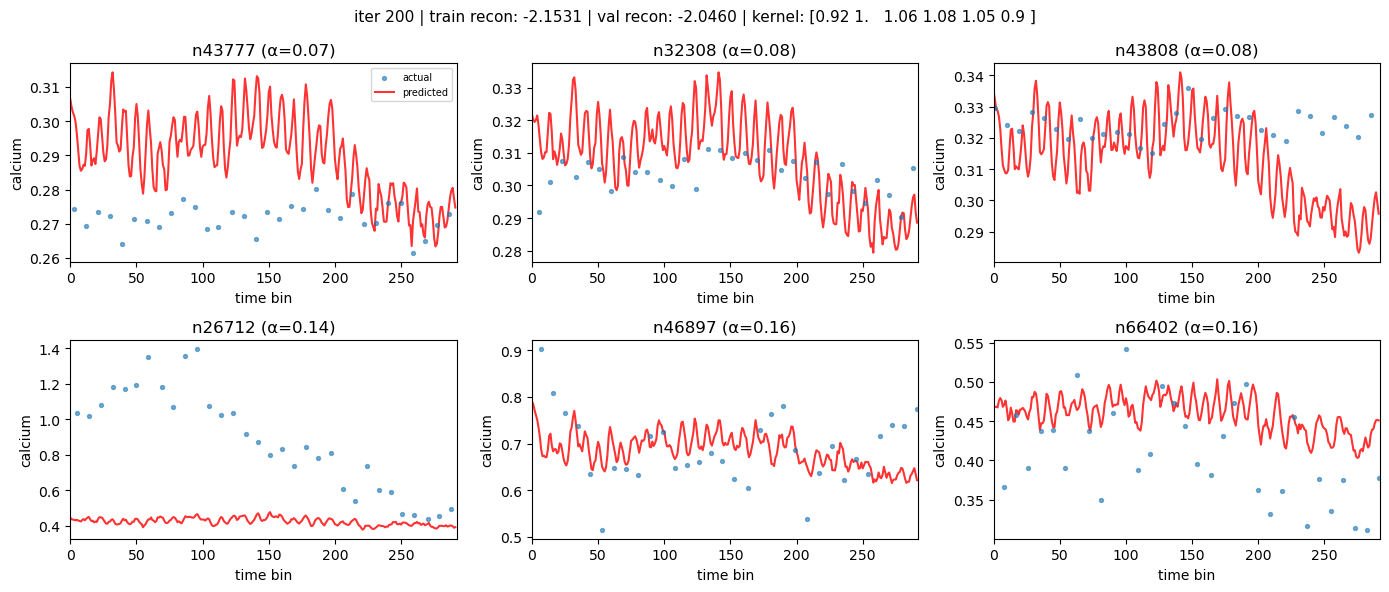

training complete


In [33]:
# disable dynamo recompilation warnings/limits for dynamic shapes
import torch._dynamo
torch._dynamo.config.suppress_errors = True
torch._dynamo.config.cache_size_limit = 256

# validation window for periodic visualization
VAL_VIZ_START = 100
VAL_VIZ_LEN = min(WINDOW_BINS_CONT, val_T - VAL_VIZ_START)


def infer_z_for_window(obs_times_cpu, obs_vals_cpu, window_start, window_len, n_iters=50):
    """infer z for a window (no decoder updates)."""
    flat_times, flat_vals, neuron_idx = extract_window_obs(
        obs_times_cpu, obs_vals_cpu, window_start, window_len
    )

    z = torch.randn(window_len, L_CONT, device=device) * 0.1
    z = nn.Parameter(z)
    z_opt = torch.optim.Adam([z], lr=LR_Z)

    for _ in range(n_iters):
        z_opt.zero_grad()
        kernel = get_kernel_cont()
        alpha = get_alpha_cont()
        sigma_sq = get_sigma_sq_cont()

        recon_loss = compute_loss_sparse_cont(
            z, flat_times, flat_vals, neuron_idx,
            kernel.detach(), alpha.detach(), sigma_sq.detach()
        )
        z_diff = z[1:] - z[:-1]
        smooth_loss = SMOOTHNESS_WEIGHT * (z_diff ** 2).mean()
        (recon_loss + smooth_loss).backward()
        z_opt.step()

    return z.detach(), flat_times, flat_vals, neuron_idx, recon_loss.item()


def visualize_val_reconstruction(iter_idx, recon_loss):
    """visualize reconstruction on validation data."""
    clear_output(wait=True)

    # infer z on validation
    z_val, flat_t, flat_v, neur_idx, val_loss = infer_z_for_window(
        val_obs_times, val_obs_vals_norm, VAL_VIZ_START, VAL_VIZ_LEN, n_iters=50
    )

    with torch.no_grad():
        calcium_pred = predict_calcium_cont(z_val, get_kernel_cont(), get_alpha_cont())

    # plot
    fig, axes = plt.subplots(2, 3, figsize=(14, 6))

    for i in range(6):
        row, col = i // 3, i % 3
        ax = axes[row, col]
        neuron = viz_neuron_idx[i].item()

        obs_t = val_obs_times[neuron].numpy()
        obs_v = val_obs_vals_norm[neuron].numpy()
        mask = (obs_t >= VAL_VIZ_START) & (obs_t < VAL_VIZ_START + VAL_VIZ_LEN)
        obs_t_rel = obs_t[mask] - VAL_VIZ_START
        obs_v_sub = obs_v[mask]

        pred_v = calcium_pred[:, neuron].cpu().numpy()

        ax.scatter(obs_t_rel, obs_v_sub, s=8, alpha=0.6, label='actual', zorder=2)
        ax.plot(pred_v, 'r-', alpha=0.8, linewidth=1.5, label='predicted', zorder=1)
        ax.set_xlabel('time bin')
        ax.set_ylabel('calcium')
        alpha_n = get_alpha_cont()[neuron].item()
        ax.set_title(f'n{neuron} (α={alpha_n:.2f})')
        ax.set_xlim(0, VAL_VIZ_LEN)
        if i == 0:
            ax.legend(loc='upper right', fontsize=7)

    plt.suptitle(f'iter {iter_idx+1} | train recon: {recon_loss:.4f} | val recon: {val_loss:.4f} | '
                 f'kernel: {get_kernel_cont().detach().cpu().numpy().round(2)}', fontsize=11)
    plt.tight_layout()
    plt.show()

    del z_val, flat_t, flat_v, neur_idx, calcium_pred
    torch.cuda.empty_cache()


# run training
n_train_iters = 200
max_start = train_T - WINDOW_BINS_CONT

recon_losses = []
smooth_losses = []

print(f"training continuous model for {n_train_iters} iterations...")

for iter_idx in tqdm(range(n_train_iters)):
    window_start = torch.randint(0, max_start, (1,)).item()

    recon, smooth = train_step_cont(
        train_obs_times, train_obs_vals_norm, window_start, WINDOW_BINS_CONT
    )

    recon_losses.append(recon)
    smooth_losses.append(smooth)

    # periodic visualization on validation
    if (iter_idx + 1) % 10 == 0:
        visualize_val_reconstruction(iter_idx, np.mean(recon_losses[-20:]))

print("training complete")

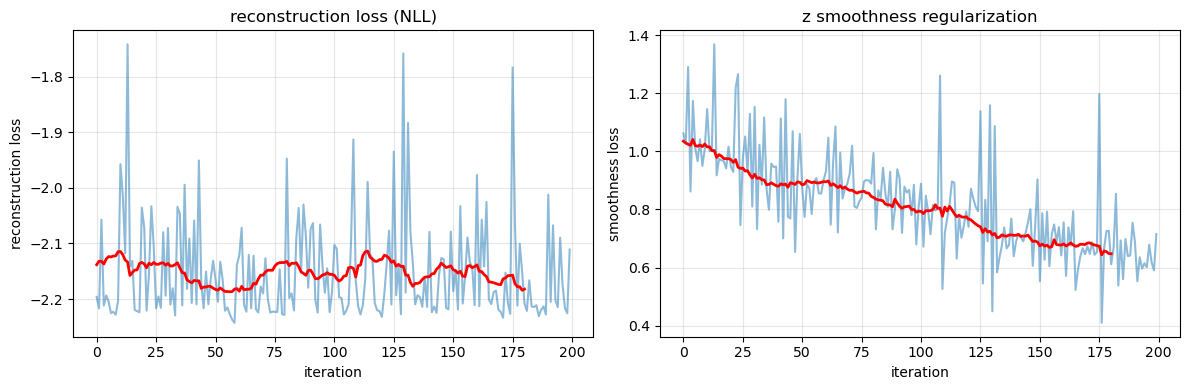

In [17]:
# plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(recon_losses, alpha=0.5)
axes[0].plot(np.convolve(recon_losses, np.ones(20)/20, mode='valid'), 'r-', linewidth=2)
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('reconstruction loss')
axes[0].set_title('reconstruction loss (NLL)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(smooth_losses, alpha=0.5)
axes[1].plot(np.convolve(smooth_losses, np.ones(20)/20, mode='valid'), 'r-', linewidth=2)
axes[1].set_xlabel('iteration')
axes[1].set_ylabel('smoothness loss')
axes[1].set_title('z smoothness regularization')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# evaluate on validation: infer z for a validation window
val_window_start = 100
val_window_len = min(WINDOW_BINS_CONT, val_T - val_window_start)

print(f"inferring z on validation window (start={val_window_start}, len={val_window_len})...")

# extract validation observations
flat_times_val, flat_vals_val, neuron_idx_val = extract_window_obs(
    val_obs_times, val_obs_vals_norm, val_window_start, val_window_len
)

# initialize and optimize z
z_val = torch.randn(val_window_len, L_CONT, device=device) * 0.1
z_val = nn.Parameter(z_val)
z_val_optimizer = torch.optim.Adam([z_val], lr=LR_Z)

# more iterations for validation inference
n_val_iters = 100
val_losses = []

for i in range(n_val_iters):
    z_val_optimizer.zero_grad()

    kernel = get_kernel_cont()
    alpha = get_alpha_cont()
    sigma_sq = get_sigma_sq_cont()

    recon_loss = compute_loss_sparse_cont(
        z_val, flat_times_val, flat_vals_val, neuron_idx_val,
        kernel.detach(), alpha.detach(), sigma_sq.detach()
    )

    z_diff = z_val[1:] - z_val[:-1]
    smooth_loss = SMOOTHNESS_WEIGHT * (z_diff ** 2).mean()

    total_loss = recon_loss + smooth_loss
    total_loss.backward()
    z_val_optimizer.step()

    val_losses.append(recon_loss.item())

print(f"validation inference complete")
print(f"  final recon loss: {val_losses[-1]:.4f}")
print(f"  z range: [{z_val.min().item():.3f}, {z_val.max().item():.3f}]")

# get predictions
with torch.no_grad():
    calcium_pred_val = predict_calcium_cont(
        z_val, get_kernel_cont(), get_alpha_cont()
    )  # (T, N)

print(f"  prediction range: [{calcium_pred_val.min().item():.3f}, {calcium_pred_val.max().item():.3f}]")

inferring z on validation window (start=100, len=292)...
validation inference complete
  final recon loss: -2.0790
  z range: [-2.918, 2.729]
  prediction range: [0.234, 1.456]


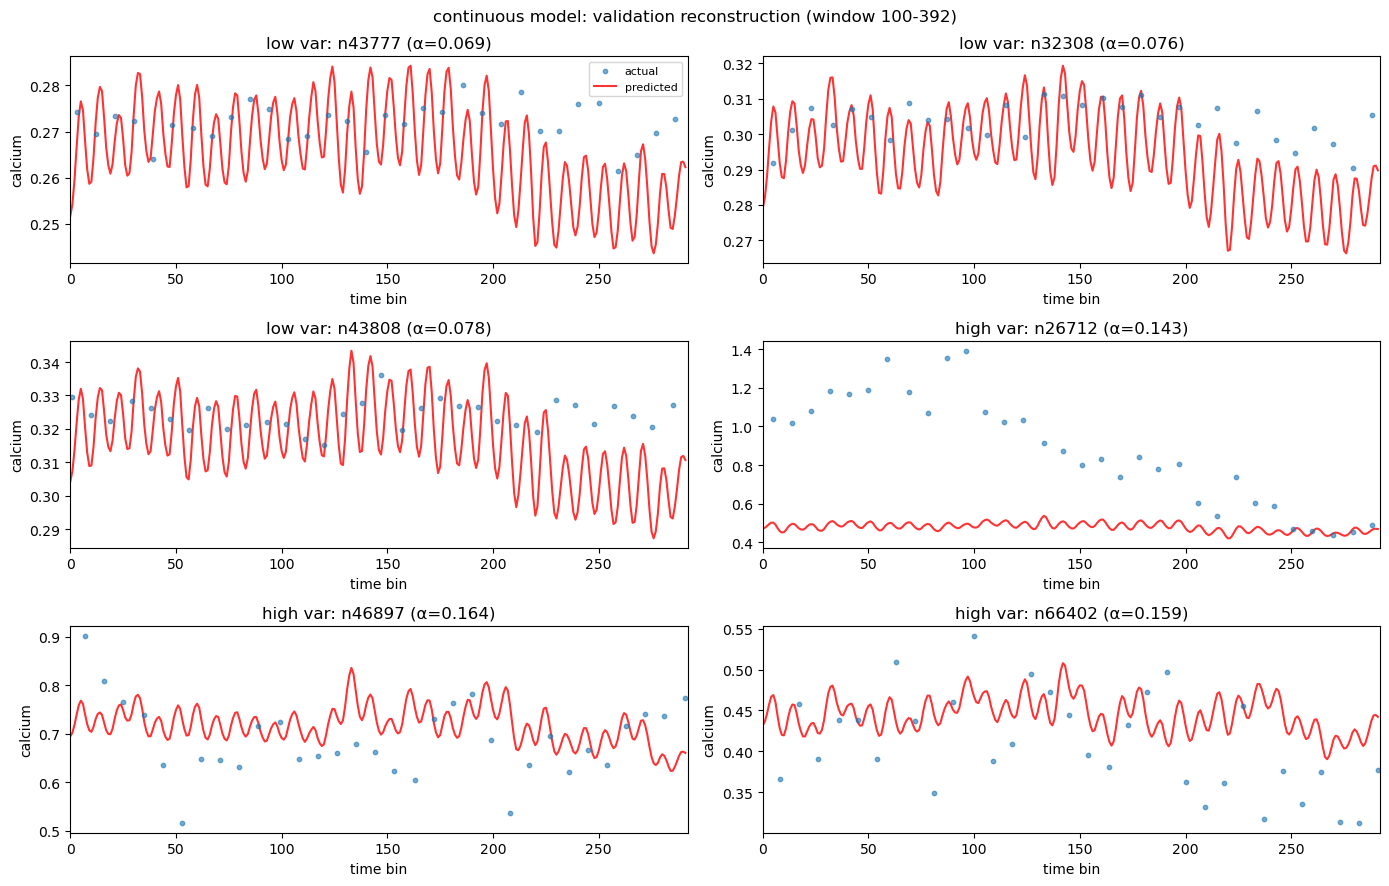

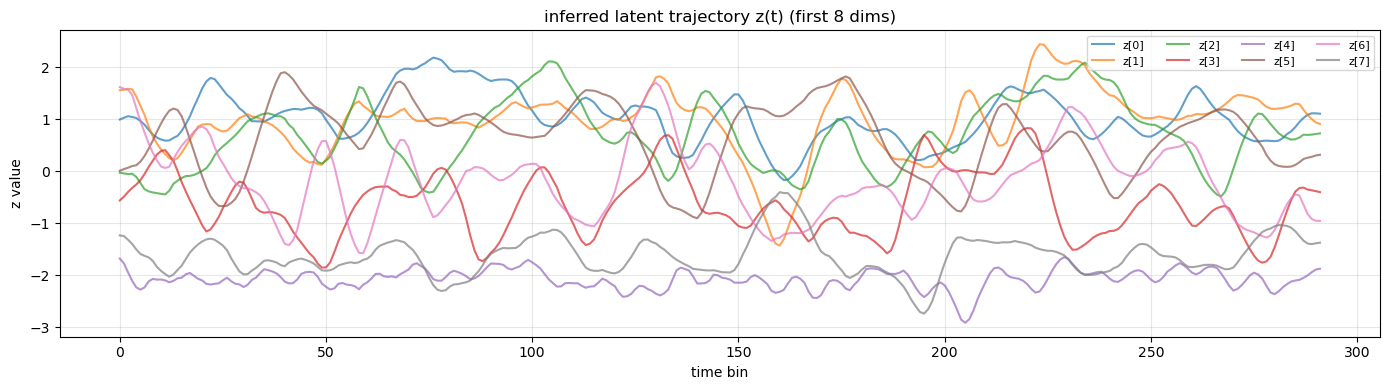

In [19]:
# visualize validation reconstructions
fig, axes = plt.subplots(3, 2, figsize=(14, 9))

for i, ax in enumerate(axes.flat):
    neuron = viz_neuron_idx[i].item()

    # get observations for this neuron in window
    obs_t = val_obs_times[neuron].numpy()
    obs_v = val_obs_vals_norm[neuron].numpy()

    mask = (obs_t >= val_window_start) & (obs_t < val_window_start + val_window_len)
    obs_t_rel = obs_t[mask] - val_window_start
    obs_v_sub = obs_v[mask]

    # get prediction
    pred_v = calcium_pred_val[:, neuron].cpu().detach().numpy()

    ax.scatter(obs_t_rel, obs_v_sub, s=10, alpha=0.6, label='actual', zorder=2)
    ax.plot(pred_v, 'r-', alpha=0.8, linewidth=1.5, label='predicted', zorder=1)

    alpha_n = get_alpha_cont()[neuron].item()
    var_label = 'low var' if i < 3 else 'high var'
    ax.set_xlabel('time bin')
    ax.set_ylabel('calcium')
    ax.set_title(f'{var_label}: n{neuron} (α={alpha_n:.3f})')
    ax.set_xlim(0, val_window_len)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.suptitle(f'continuous model: validation reconstruction (window {val_window_start}-{val_window_start+val_window_len})',
             fontsize=12)
plt.tight_layout()
plt.show()

# also show z trajectory
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
z_np = z_val.detach().cpu().numpy()
for dim in range(min(8, L_CONT)):
    ax.plot(z_np[:, dim], label=f'z[{dim}]', alpha=0.7)
ax.set_xlabel('time bin')
ax.set_ylabel('z value')
ax.set_title('inferred latent trajectory z(t) (first 8 dims)')
ax.legend(loc='upper right', ncol=4, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# compute validation metrics on inferred window
with torch.no_grad():
    # predictions at observation locations
    pred_at_obs = calcium_pred_val[flat_times_val, neuron_idx_val]

    # metrics
    mse = F.mse_loss(pred_at_obs, flat_vals_val).item()
    mae = (pred_at_obs - flat_vals_val).abs().mean().item()

    # correlation
    pred_c = pred_at_obs - pred_at_obs.mean()
    actual_c = flat_vals_val - flat_vals_val.mean()
    corr = (pred_c * actual_c).sum() / (pred_c.norm() * actual_c.norm() + 1e-8)

print(f"validation metrics (continuous model):")
print(f"  MSE: {mse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  correlation: {corr.item():.4f}")
print(f"  n_observations: {flat_vals_val.shape[0]}")

# per-neuron correlation
per_neuron_corr_cont = []
neuron_idx_np = neuron_idx_val.cpu().numpy()
flat_times_np = flat_times_val.cpu().numpy()
flat_vals_np = flat_vals_val.cpu().numpy()
pred_np = pred_at_obs.cpu().numpy()

for n in range(N):
    mask = neuron_idx_np == n
    if mask.sum() < 2:
        per_neuron_corr_cont.append(0.0)
        continue

    actual = flat_vals_np[mask]
    pred = pred_np[mask]

    a_c = actual - actual.mean()
    p_c = pred - pred.mean()

    if np.linalg.norm(a_c) < 1e-8 or np.linalg.norm(p_c) < 1e-8:
        per_neuron_corr_cont.append(0.0)
        continue

    corr_n = np.dot(a_c, p_c) / (np.linalg.norm(a_c) * np.linalg.norm(p_c))
    per_neuron_corr_cont.append(corr_n)

per_neuron_corr_cont = np.array(per_neuron_corr_cont)

print(f"\nper-neuron correlation (continuous model):")
print(f"  mean: {np.mean(per_neuron_corr_cont):.4f}")
print(f"  median: {np.median(per_neuron_corr_cont):.4f}")
print(f"  std: {np.std(per_neuron_corr_cont):.4f}")

plt.figure(figsize=(8, 4))
plt.hist(per_neuron_corr_cont, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('correlation')
plt.ylabel('count')
plt.title('per-neuron prediction correlation (continuous model)')
plt.axvline(np.mean(per_neuron_corr_cont), color='r', linestyle='--',
            label=f'mean={np.mean(per_neuron_corr_cont):.3f}')
plt.legend()
plt.show()

validation metrics (continuous model):
  MSE: 0.0045
  MAE: 0.0406
  correlation: 0.4368
  n_observations: 2294902


KeyboardInterrupt: 